# End-to-end inference on a public breast cancer H&E image

This executable tutorial runs HistoOmniST on the 10x Genomics
`Xenium_FFPE_Human_Breast_Cancer_Rep1_he_image.ome.tif` section.
This is the public breast cancer section used for the manuscript's
Xenium discussion example. It exposes every major step: verified asset
download, image inspection,
tissue masking, tile selection, HIPT feature extraction, spatial-context
construction, expression-rate and SF prediction, count-scale
reconstruction, and spatial plotting.

The first run downloads about 2.2 GB: two HistoOmniST checkpoints, the
original HIPT ViT-256 source and weight, and the 1.43 GB public H&E image.
A CUDA GPU is strongly recommended for the approximately 12,000-tile
example. Generated data stay under ignored `data/` and `outputs/`
directories and are not part of the Git repository.


In [1]:
from contextlib import redirect_stdout
from io import StringIO
from pathlib import Path
import json
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display


def find_project_root(start: Path) -> Path:
    for candidate in (start.resolve(), *start.resolve().parents):
        if (candidate / "pyproject.toml").exists() and (candidate / "src/histoomnist").exists():
            return candidate
    raise RuntimeError("Run this notebook from inside the HistoOmniST repository.")


ROOT = find_project_root(Path.cwd())
sys.path.insert(0, str(ROOT / "src"))
sys.path.insert(0, str(ROOT / "scripts"))

from download_example_data import download_example
from download_hipt_assets import download_hipt_assets
from download_release_models import download_asset
from histoomnist.features.patch_features import hipt256_features, load_hipt256_model
import histoomnist_predict_uploaded_wsi as wsi

get_ipython().run_line_magic("matplotlib", "inline")

OUT_DIR = ROOT / "outputs" / "example_breast_xenium"
OUT_DIR.mkdir(parents=True, exist_ok=True)
print("Project root: .")
print("Output directory:", OUT_DIR.relative_to(ROOT).as_posix())


Project root: .
Output directory: outputs/example_breast_xenium


## 1. Download and verify the public assets

The HistoOmniST checkpoints come from the project release. HIPT source
and weights come directly from the original
[`mahmoodlab/HIPT`](https://github.com/mahmoodlab/HIPT) project at a
pinned revision. The H&E image comes from the official 10x Genomics CDN.
Every file is checked against the byte count and SHA-256 stored in a
committed manifest.


In [2]:
release_manifest_path = ROOT / "models" / "release_manifest.json"
release_manifest = json.loads(release_manifest_path.read_text(encoding="utf-8"))

download_log = StringIO()
with redirect_stdout(download_log):
    model_paths = {
        asset["id"]: download_asset(asset, root=ROOT)
        for asset in release_manifest["assets"]
    }
    hipt_paths = download_hipt_assets(
        manifest_path=release_manifest_path,
        root=ROOT,
    )
    slide_path = download_example(
        manifest_path=ROOT / "examples/breast_xenium/example_manifest.json",
        root=ROOT,
    )

asset_paths = {**model_paths, **hipt_paths, "breast_xenium_rep1_he": slide_path}
print(f"Verified {len(asset_paths)} required assets from committed manifests.")
asset_table = pd.DataFrame(
    [
        {
            "asset": name,
            "path": path.relative_to(ROOT).as_posix(),
            "size_MiB": path.stat().st_size / 2**20,
        }
        for name, path in asset_paths.items()
    ]
)
display(asset_table.round({"size_MiB": 2}))


Verified 5 required assets from committed manifests.


,asset,path,size_MiB
0,expression_rate,checkpoints/hest1k_human_visium_expression/hig...,21.79
1,size_factor,checkpoints/hest1k_human_visium_sf/context_dis...,48.52
2,hipt_vision_transformer_source,third_party/HIPT/1-Hierarchical-Pretraining/vi...,0.01
3,hipt_vit256_weights,third_party/HIPT/HIPT_4K/Checkpoints/vit256_sm...,671.61
4,breast_xenium_rep1_he,data/examples/breast_xenium/Xenium_FFPE_Human_...,1361.00


## 2. Open the whole-slide image

The reader keeps the full-resolution OME-TIFF on disk and accesses only
the pyramid level or tile required at each step. The thumbnail below is
used for tissue detection; HIPT later receives full-resolution 224 x 224
RGB tiles.


Reader: tifffile_zarr
Full resolution: 30,786 x 24,241 pixels
Thumbnail: 1,924 x 1,515 pixels


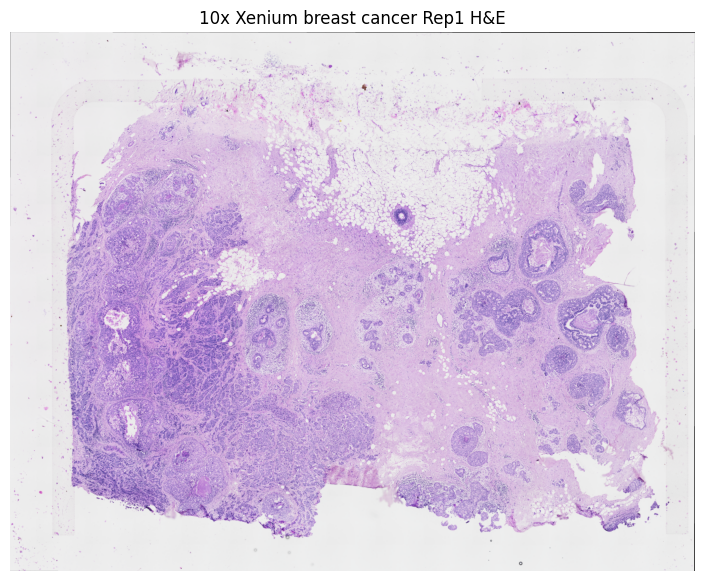

In [3]:
slide, reader = wsi.open_slide(slide_path)
slide_width, slide_height = slide.dimensions
thumbnail = slide.get_thumbnail((2048, 2048)).convert("RGB")

print(f"Reader: {reader}")
print(f"Full resolution: {slide_width:,} x {slide_height:,} pixels")
print(f"Thumbnail: {thumbnail.width:,} x {thumbnail.height:,} pixels")

fig, ax = plt.subplots(figsize=(9, 7))
ax.imshow(thumbnail)
ax.set_title("10x Xenium breast cancer Rep1 H&E")
ax.axis("off")
plt.show()


## 3. Detect tissue and define the prediction grid

HistoOmniST predicts one virtual spatial transcriptome per retained tile.
This example uses the deployment settings used by the public interface:
224 x 224 pixel tiles, at least 25% tissue, and an adaptive stride that
targets approximately 12,000 tissue tiles without exceeding 15,000.


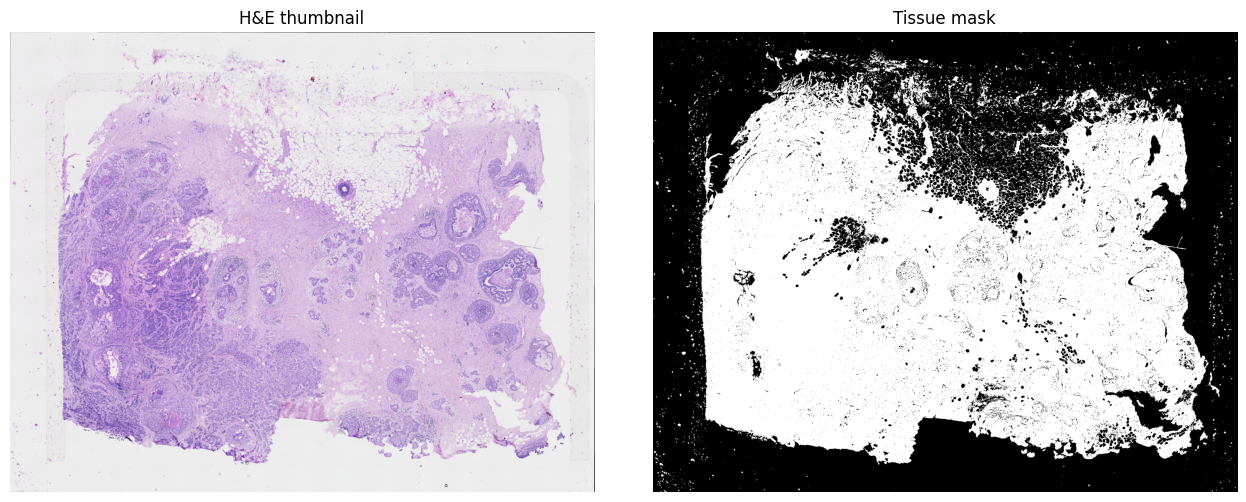

In [4]:
thumbnail_rgb = np.asarray(thumbnail)
tissue_mask = wsi.rgb_tissue_mask(thumbnail_rgb)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].imshow(thumbnail_rgb)
axes[0].set_title("H&E thumbnail")
axes[1].imshow(tissue_mask, cmap="gray")
axes[1].set_title("Tissue mask")
for ax in axes:
    ax.axis("off")
plt.tight_layout()
plt.show()


Effective stride: 192 pixels
Retained tissue tiles: 11,831


,stride,estimated_tissue_tiles
0,1024,418
1,768,729
2,512,1664
3,384,2953
4,320,4259
5,256,6632
6,224,8733
7,192,11831
8,160,17055
9,128,26612


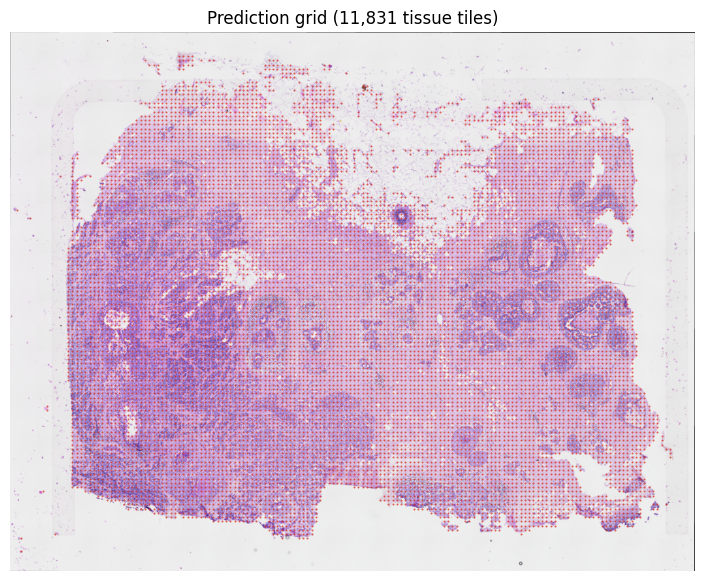

In [5]:
TILE_SIZE = 224
REQUESTED_STRIDE = 1024
TARGET_TILES = 12_000
MIN_STRIDE = 128
MAX_TILES = 15_000
TISSUE_THRESHOLD = 0.25

effective_stride, stride_diagnostics = wsi.choose_adaptive_stride(
    width=slide_width,
    height=slide_height,
    tile_size=TILE_SIZE,
    requested_stride=REQUESTED_STRIDE,
    mask=tissue_mask,
    tissue_threshold=TISSUE_THRESHOLD,
    max_tiles=MAX_TILES,
    target_tiles=TARGET_TILES,
    min_stride=MIN_STRIDE,
)
tiles = wsi.select_tile_grid(
    width=slide_width,
    height=slide_height,
    tile_size=TILE_SIZE,
    stride=effective_stride,
    mask=tissue_mask,
    tissue_threshold=TISSUE_THRESHOLD,
    max_tiles=MAX_TILES,
)

print(f"Effective stride: {effective_stride} pixels")
print(f"Retained tissue tiles: {len(tiles):,}")
display(pd.DataFrame(stride_diagnostics["candidate_estimates"]))

tx = (tiles["x"] + TILE_SIZE / 2) / slide_width * thumbnail.width
ty = (tiles["y"] + TILE_SIZE / 2) / slide_height * thumbnail.height
fig, ax = plt.subplots(figsize=(9, 7))
ax.imshow(thumbnail)
ax.scatter(tx, ty, s=2, c="#d7301f", linewidths=0, alpha=0.75)
ax.set_title(f"Prediction grid ({len(tiles):,} tissue tiles)")
ax.axis("off")
plt.show()


## 4. Extract HIPT ViT-256 features

The original HIPT ViT-256 encoder maps each full-resolution RGB tile to
a 384-dimensional morphology vector. The feature matrix is cached with
its exact tile grid, so an interrupted notebook can resume without
repeating feature extraction.


In [6]:
import torch

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
BATCH_SIZE = 64 if DEVICE == "cuda" else 16
feature_path = OUT_DIR / "hipt256_features.npy"
feature_grid_path = OUT_DIR / "hipt256_feature_grid.csv"
grid_columns = ["tile_index", "x", "y", "tile_size", "stride", "tissue_fraction"]

cache_matches = False
if feature_path.exists() and feature_grid_path.exists():
    cached_grid = pd.read_csv(feature_grid_path)
    cache_matches = cached_grid[grid_columns].equals(tiles[grid_columns])

if cache_matches:
    raw_features = np.load(feature_path)
    print("Loaded cached HIPT features:", raw_features.shape)
else:
    hipt_model = load_hipt256_model(
        hipt_source_dir=hipt_paths["hipt_vision_transformer_source"].parent,
        weights_path=hipt_paths["hipt_vit256_weights"],
        device=DEVICE,
    )
    feature_batches = []
    for start in range(0, len(tiles), BATCH_SIZE):
        stop = min(start + BATCH_SIZE, len(tiles))
        images = wsi.read_tile_batch(slide, tiles, TILE_SIZE, start, stop)
        feature_batches.append(hipt256_features(images, hipt_model, device=DEVICE))
    raw_features = np.concatenate(feature_batches, axis=0).astype(np.float32)
    np.save(feature_path, raw_features)
    tiles[grid_columns].to_csv(feature_grid_path, index=False)
    print("Extracted and cached HIPT features:", raw_features.shape)

slide.close()
assert raw_features.shape == (len(tiles), 384)


Extracted and cached HIPT features: (11831, 384)


## 5. Build spatial context and load both HistoOmniST branches

Each checkpoint expects 1,161 inputs: the 384-dimensional local HIPT
vector, mean HIPT vectors from two spatial neighbourhoods, and nine
coordinate/density descriptors. The training-set feature mean and
standard deviation stored in each checkpoint are applied only inside the
corresponding prediction function.


In [7]:
rate_model, checkpoint_genes, rate_mean, rate_std = wsi.load_rate_model(
    model_paths["expression_rate"],
    device=DEVICE,
)
sf_model, sf_mean, sf_std = wsi.load_sf_model(
    ROOT / "configs/hest1k_human_visium_sf_context_distribution_light.yaml",
    model_paths["size_factor"],
    device=DEVICE,
)

rate_features = wsi.features_for_checkpoint(
    raw_features,
    tiles,
    expected_dim=rate_mean.shape[0],
)
sf_features = (
    rate_features
    if sf_mean.shape[0] == rate_features.shape[1]
    else wsi.features_for_checkpoint(raw_features, tiles, expected_dim=sf_mean.shape[0])
)
print("Raw HIPT features:", raw_features.shape)
print("Rate-branch context features:", rate_features.shape)
print("SF-branch context features:", sf_features.shape)


Raw HIPT features: (11831, 384)
Rate-branch context features: (11831, 1161)
SF-branch context features: (11831, 1161)


## 6. Predict expression rate and slide-normalized SF

The expression branch predicts `log1p(rate)` for selected genes. The SF
branch predicts `log(SF)` and `predict_sf` exponentiates and normalizes
those values so the arithmetic mean of SF over this slide is one.


In [8]:
panel = json.loads(
    (ROOT / "configs/manuscript_release_28_gene_panel.json").read_text(encoding="utf-8")
)
gene_to_index = {gene: index for index, gene in enumerate(checkpoint_genes)}
selected_genes = [gene for gene in panel["selected_genes"] if gene in gene_to_index]
selected_indices = [gene_to_index[gene] for gene in selected_genes]

pred_log1p_rate = wsi.predict_rate_selected(
    features=rate_features,
    model=rate_model,
    mean=rate_mean,
    std=rate_std,
    selected_indices=selected_indices,
    device=DEVICE,
    batch_size=BATCH_SIZE,
)
pred_log_sf, pred_sf = wsi.predict_sf(
    features=sf_features,
    model=sf_model,
    mean=sf_mean,
    std=sf_std,
    device=DEVICE,
    batch_size=BATCH_SIZE,
)

print("Rate output:", pred_log1p_rate.shape)
print(f"Predicted SF mean: {pred_sf.mean():.8f}")
print(f"Predicted SF range: {pred_sf.min():.3f} to {pred_sf.max():.3f}")
assert np.isclose(pred_sf.mean(), 1.0, atol=1e-6)


Rate output: (11831, 28)
Predicted SF mean: 1.00000000
Predicted SF range: 0.015 to 3.635


## 7. Reconstruct count-scale virtual expression

For every tile `i` and gene `g`, the canonical downstream value is:

```text
rate[i,g] = max(expm1(pred_log1p_rate[i,g]), 0)
count[i,g] = rate[i,g] * pred_sf[i]
count_log1p[i,g] = log1p(count[i,g])
```

Programs are means of the available `count_log1p` member genes. Rate is
never multiplied by SF while it is still on the `log1p` scale.


In [9]:
predictions = tiles.copy()
predictions["pred_log_sf"] = pred_log_sf
predictions["pred_sf"] = pred_sf
for column_index, gene in enumerate(selected_genes):
    predictions[f"gene_{gene}"] = pred_log1p_rate[:, column_index]

predictions = wsi.add_count_columns(predictions, selected_genes)
predictions, used_programs = wsi.compute_programs(
    predictions,
    selected_genes,
    panel["programs"],
)
predictions = wsi.promote_count_log1p_gene_aliases(predictions, selected_genes)

prediction_path = OUT_DIR / "rep1_tile_predictions.csv"
predictions.to_csv(prediction_path, index=False)
print("Saved:", prediction_path.relative_to(ROOT).as_posix())
print("Programs:", used_programs)
display(
    predictions[
        ["x", "y", "pred_sf", "rate_log1p_EPCAM", "count_EPCAM", "count_log1p_EPCAM"]
    ].head()
)


Saved: outputs/example_breast_xenium/rep1_tile_predictions.csv
Programs: {'epithelial': ['EPCAM', 'KRT8'], 't_cell': ['CD3D', 'CD3E', 'CD8A', 'CD4'], 'myeloid': ['LST1', 'AIF1', 'C1QA', 'C1QB'], 'stromal': ['COL1A1', 'COL1A2', 'DCN', 'LUM', 'ACTA2'], 'proliferation': ['MKI67', 'TOP2A', 'PCNA'], 'hypoxia': ['CA9', 'SLC2A1'], 'emt_tgfb': ['VIM', 'TGFB1', 'ZEB1', 'SNAI2'], 'wnt_crc': ['AXIN2', 'LGR5', 'MYC', 'ASCL2']}


,x,y,pred_sf,rate_log1p_EPCAM,count_EPCAM,count_log1p_EPCAM
0,7488,960,0.071181,0.236318,0.018975,0.018797
1,7680,960,0.123975,0.256609,0.036268,0.035625
2,7872,960,0.119182,0.234400,0.031482,0.030997
3,8064,960,0.135816,0.343271,0.055624,0.054132
4,5952,1152,0.314912,0.182779,0.063155,0.061241


## 8. Plot the reconstructed spatial signals

All gene and program panels below use reconstructed `count_log1p` values.
The H&E image is shown only as spatial context; these maps are model
predictions, not measured Xenium expression.


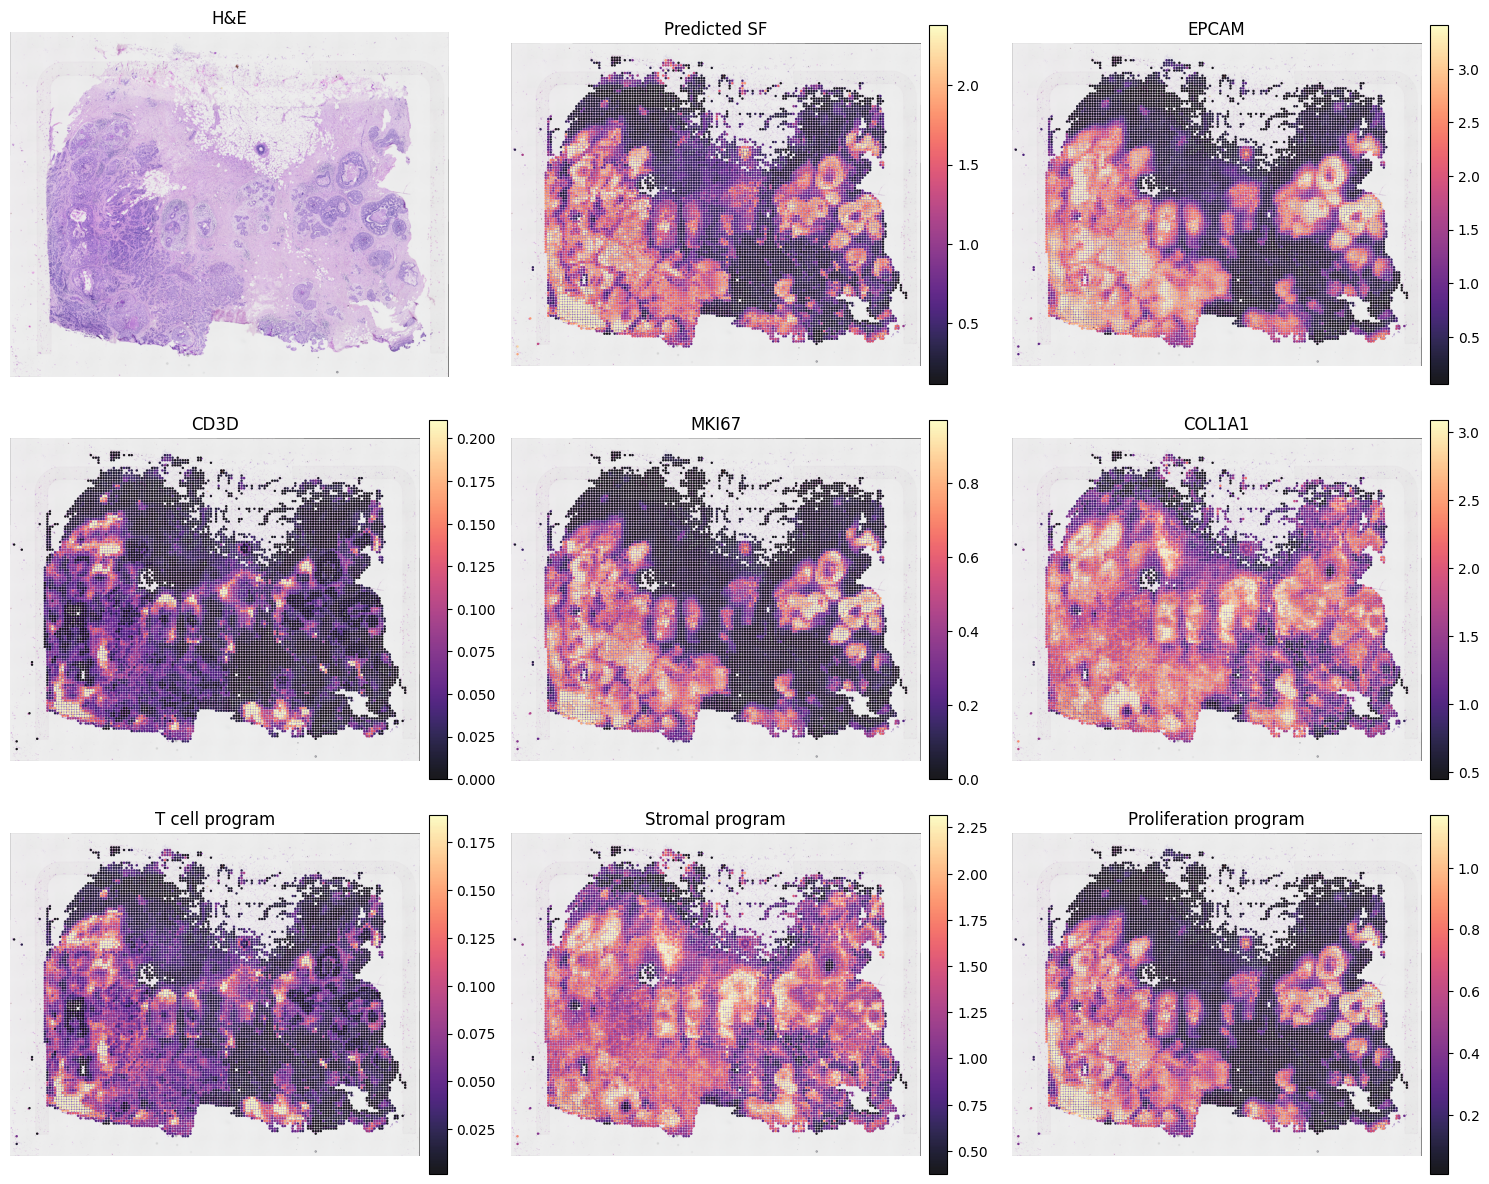

Saved: outputs/example_breast_xenium/rep1_count_scale_spatial_maps.png


In [10]:
plot_panels = [
    ("H&E", None),
    ("Predicted SF", "pred_sf"),
    ("EPCAM", "count_log1p_EPCAM"),
    ("CD3D", "count_log1p_CD3D"),
    ("MKI67", "count_log1p_MKI67"),
    ("COL1A1", "count_log1p_COL1A1"),
    ("T cell program", "program_t_cell"),
    ("Stromal program", "program_stromal"),
    ("Proliferation program", "program_proliferation"),
]

tx = (predictions["x"] + TILE_SIZE / 2) / slide_width * thumbnail.width
ty = (predictions["y"] + TILE_SIZE / 2) / slide_height * thumbnail.height
fig, axes = plt.subplots(3, 3, figsize=(15, 12))
for ax, (title, column) in zip(axes.flat, plot_panels):
    ax.imshow(thumbnail)
    ax.set_title(title)
    ax.axis("off")
    if column is None or column not in predictions:
        continue
    values = predictions[column].to_numpy(float)
    lo, hi = np.nanpercentile(values, [2, 98])
    if not np.isfinite(lo) or not np.isfinite(hi) or hi <= lo:
        lo, hi = float(np.nanmin(values)), float(np.nanmax(values) + 1e-6)
    points = ax.scatter(
        tx,
        ty,
        c=values,
        s=3,
        cmap="magma",
        vmin=lo,
        vmax=hi,
        linewidths=0,
        alpha=0.9,
    )
    fig.colorbar(points, ax=ax, fraction=0.046, pad=0.02)

fig.tight_layout()
figure_path = OUT_DIR / "rep1_count_scale_spatial_maps.png"
fig.savefig(figure_path, dpi=220, bbox_inches="tight")
plt.show()
print("Saved:", figure_path.relative_to(ROOT).as_posix())


In [11]:
summary = {
    "input": slide_path.relative_to(ROOT).as_posix(),
    "reader": reader,
    "slide_dimensions": [slide_width, slide_height],
    "tile_size": TILE_SIZE,
    "effective_stride": effective_stride,
    "n_tiles": len(predictions),
    "n_genes": len(selected_genes),
    "mean_predicted_sf": float(predictions["pred_sf"].mean()),
    "prediction_csv": prediction_path.relative_to(ROOT).as_posix(),
    "spatial_figure": figure_path.relative_to(ROOT).as_posix(),
}
summary_path = OUT_DIR / "notebook_run_summary.json"
summary_path.write_text(json.dumps(summary, indent=2), encoding="utf-8")
display(pd.Series(summary, name="value").to_frame())


,value
input,data/examples/breast_xenium/Xenium_FFPE_Human_...
reader,tifffile_zarr
slide_dimensions,"[30786, 24241]"
tile_size,224
effective_stride,192
n_tiles,11831
n_genes,28
mean_predicted_sf,1.0
prediction_csv,outputs/example_breast_xenium/rep1_tile_predic...
spatial_figure,outputs/example_breast_xenium/rep1_count_scale...
